In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import sys
sys.path.append('..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinFoldingResult
from vqe import VQEC, PerturbedPrimalDualOpt, DualDecompOpt, VQECResult
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes, EfficientSU2, TwoLocal
from qiskit.primitives import Sampler
# from qiskit_aer.primitives import Estimator, Sampler
from qiskit_aer.primitives import Estimator
from qiskit_algorithms.gradients import LinCombEstimatorGradient, ParamShiftEstimatorGradient, FiniteDiffEstimatorGradient
import numpy as np
import matplotlib.pyplot as plt
from qufold.execution_utils.measurements import _evaluate_sparsepauli
from qiskit.quantum_info import SparsePauliOp
import json
import os

In [3]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    penalty_olap = None

    penalty_terms = PenaltyParameters(
        penalty_back=penalty_back,
        penalty_redun=penalty_redun,
        penalty_olap=penalty_olap,
    )

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(
        peptide, mj_interaction, penalty_terms
    )

    return protein_folding_problem

## Single run workflow

In [4]:
main_seq = "KLVFFA" # 6MVZ ("LFLF")YYDPETGTWY
protein_folding_problem = build_pf(main_seq)
qubit_op = protein_folding_problem.qubit_op()
print(f"Number of qubits: {qubit_op.num_qubits}")
print(f"Number of terms: {len(qubit_op)}")

[[ 0.   -3.37 -2.49 -3.36 -3.36 -1.31]
 [ 0.    0.   -6.48 -7.28 -7.28 -4.91]
 [ 0.    0.    0.   -6.29 -6.29 -4.04]
 [ 0.    0.    0.    0.   -7.26 -4.81]
 [ 0.    0.    0.    0.    0.   -4.81]
 [ 0.    0.    0.    0.    0.    0.  ]]
Number of qubits: 24
Number of terms: 2199


In [5]:
bead_pairs, olap_constr_ops = protein_folding_problem.olap_constr_ops()
print(f"Number of overlap constraints: {len(olap_constr_ops)}")
print(f"Number of qubits: {olap_constr_ops[0].num_qubits}")

Number of overlap constraints: 6
Number of qubits: 24


In [49]:
ansatz = TwoLocal(
    qubit_op.num_qubits,
    ["ry"],
    "cx",
    reps=1,
    entanglement="linear",
    skip_final_rotation_layer=True,
)
estimator = Estimator(
    backend_options={"method": "matrix_product_state"},
    run_options={"shots": None},
    approximation=True,
)
# estimator = Estimator()
gradient = ParamShiftEstimatorGradient(estimator=estimator)

init_dual_vars = np.array([0.0] * len(olap_constr_ops))
perturb_step = 0.05
gamma = 0.1
max_iter = 800

vqec = PerturbedPrimalDualOpt(
    qubit_op=qubit_op,
    constr_ops=olap_constr_ops,
    ansatz=ansatz,
    estimator=estimator,
    gradient=gradient,
)

vqec_result = vqec.optimize_primal_dual(
    initial_dual_vars=init_dual_vars,
    primal_perturb_step=perturb_step,
    dual_perturb_step=perturb_step,
    gamma=gamma,
    auto_update_step=False,
    max_iter=max_iter,
)

print(vqec_result.optimal_primal_vars)
print(vqec_result.optimal_dual_vars)
print(f"Optimal energy: {vqec_result.energies[-1]}")

100%|██████████| 800/800 [1:07:05<00:00,  5.03s/it]

[6.28276012e+00 2.74688678e+00 1.03560190e+00 3.14159265e+00
 6.28318531e+00 3.14159265e+00 6.28317226e+00 3.14159265e+00
 3.14168330e+00 2.68119931e-07 9.88051158e-03 6.28300754e+00
 9.10234587e-02 6.28318531e+00 4.01986610e-02 6.18126949e+00
 3.09173389e+00 3.34226721e+00 3.37936058e+00 6.23596069e+00
 3.12996749e+00 3.23251303e+00 6.20278929e+00 7.30866684e-02]
[0. 0. 0. 0. 0. 0.]
Optimal energy: -0.33412658154731734


In [57]:
vqec_result.constraints

array([[-3.55283159, -6.38819151, -6.77674217, -4.33506939, -5.97713091,
        -3.7282602 ],
       [-2.07829754, -4.99264001, -6.07693457, -4.50769071, -6.97141914,
        -4.19710651],
       [-0.75037638, -3.35717194, -5.03976147, -4.1480325 , -7.35365799,
        -4.31856701],
       ...,
       [-1.20994182, -3.05463145, -3.25523577, -0.94074595, -0.08730191,
        -0.94609471],
       [-1.20993786, -3.05462269, -3.25523345, -0.9407574 , -0.08730538,
        -0.94608026],
       [-1.20993394, -3.05461402, -3.25523115, -0.94076875, -0.08730882,
        -0.94606597]])

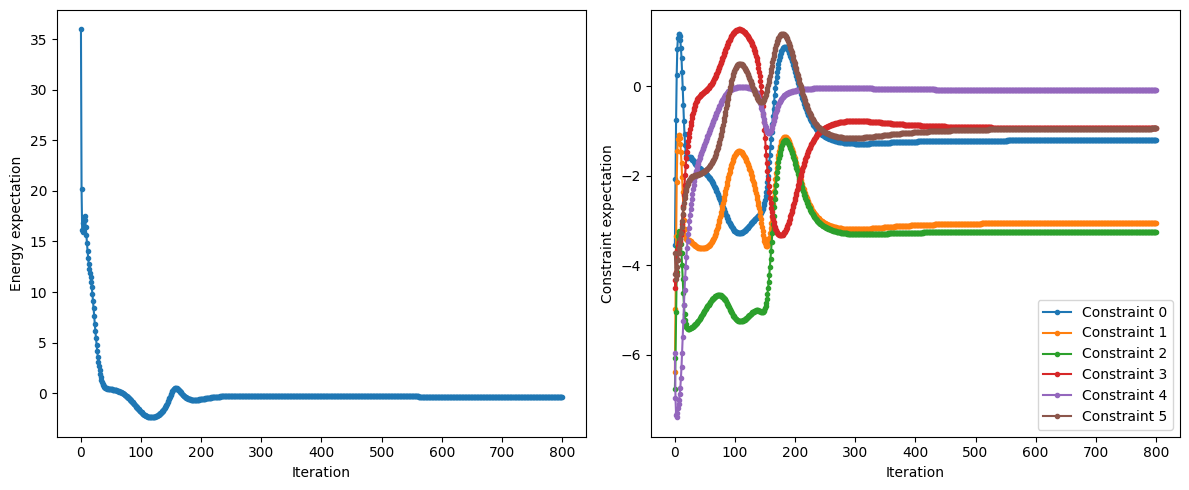

In [60]:
# Plot the results
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(vqec_result.energies, label="Energy", marker=".")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Energy expectation")

for i, constr_op in enumerate(olap_constr_ops):
    ax[1].plot(
        vqec_result.constraints[:, i],
        label=f"Constraint {i}",
        marker=".",
    )
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Constraint expectation")
ax[1].legend()

# ax[2].plot(vqec_result.lagrangian_gap_trajectory, label="Dual", marker=".")
# ax[2].set_xlabel("Iteration")
# ax[2].set_ylabel("Lagrangian gap trajectory")

plt.tight_layout()
plt.show()

In [52]:
full_circ = vqec_result.ansatz.copy()
full_circ.measure_all()
sampler = Sampler(options={"shots": 50000})
# sampler = Sampler(run_options={"shots": 10000})
sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_result.optimal_primal_vars).result()
quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()

# Sort the binary strings by their probabilities
sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))
# Compute the energies of all samples
from qufold.execution_utils.measurements import _evaluate_sparsepauli
bitstring_energies = {}
for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
    if i >= 5:
        break
    energy = _evaluate_sparsepauli(sample, qubit_op)
    bitstring_energies[sample] = energy
    print(f"Sample {i}: {sample} with probability {prob} and energy {energy}")

/var/folders/f0/3f43g55s7jj8xnhyp1dq2nfh0000gn/T/ipykernel_5287/2057137825.py:3: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": 50000})


Sample 0: 000100101111111101100110 with probability 0.70092 and energy -0.011000000000002536
Sample 1: 111011010000000010011010 with probability 0.2262 and energy -1.202000000000001
Sample 2: 111011010000000010011000 with probability 0.02876 and energy -5.570000000000003
Sample 3: 111011101111111101100110 with probability 0.0106 and energy 0.24199999999999738
Sample 4: 000100101111111101100100 with probability 0.009 and energy 10.605


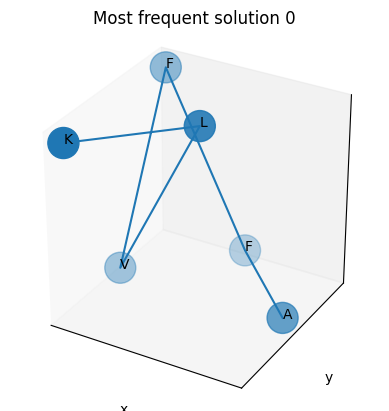

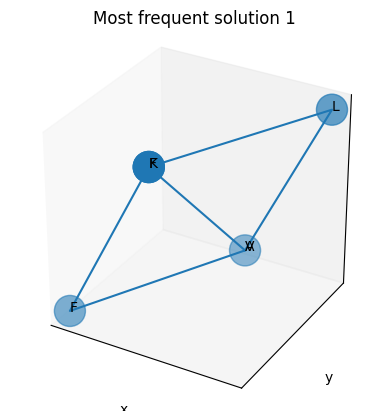

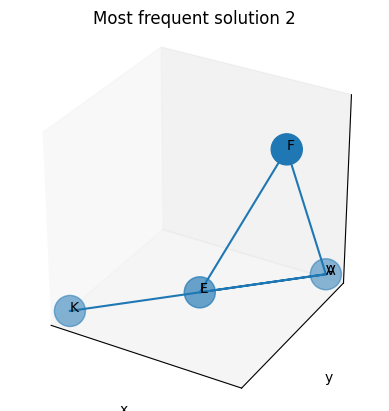

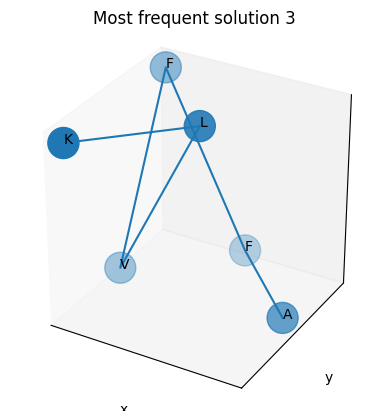

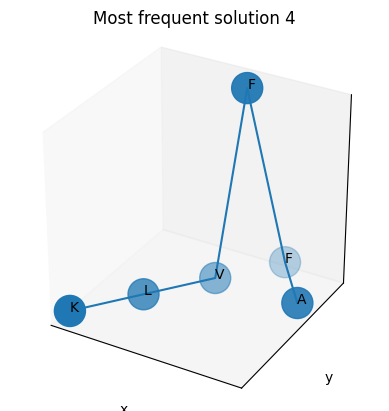

In [53]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    fig = pf_result.get_figure(title=f"Most frequent solution {i}")
    plt.show()

## Parallelized runs workflow

In [22]:
import ray

In [23]:
@ray.remote
def _optimize_ray(
    ppd_opt: PerturbedPrimalDualOpt,
    init_params: np.ndarray | None = None,
    init_dual_vars: np.ndarray | None = None,
    primal_perturb_step: float = 0.05,
    dual_perturb_step: float = 0.05,
    primal_dual_update_step: float = 1,
    max_iter: int = 300,
) -> VQECResult:
    """Optimize the given problem using the Perturbed Primal Dual method."""
    return ppd_opt.optimize_primal_dual(
        initial_params=init_params,
        initial_dual_vars=init_dual_vars,
        primal_perturb_step=primal_perturb_step,
        dual_perturb_step=dual_perturb_step,
        gamma=primal_dual_update_step,
        max_iter=max_iter,
    )

In [27]:
ray.shutdown()

In [24]:
import psutil
import vqe

num_cpus = psutil.cpu_count(logical=False)
print(f"Number of CPUs: {num_cpus}")
ray.init(
    ignore_reinit_error=True,
    num_cpus=num_cpus,
    runtime_env={
        "py_modules": [vqe],
    },
)

Number of CPUs: 12


2025-05-02 16:31:30,233	INFO worker.py:1772 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
2025-05-02 16:31:30,251	INFO packaging.py:530 -- Creating a file package for local directory '/Users/lir9/protein-folding-qc/notebooks/../vqe'.
2025-05-02 16:31:30,264	INFO packaging.py:358 -- Pushing file package 'gcs://_ray_pkg_bd531a8483bea683.zip' (0.07MiB) to Ray cluster...
2025-05-02 16:31:30,265	INFO packaging.py:371 -- Successfully pushed file package 'gcs://_ray_pkg_bd531a8483bea683.zip'.


Python version:,3.12.2
Ray version:,2.34.0
Dashboard:,http://127.0.0.1:8265


100%|██████████| 5/5 [00:25<00:00,  5.08s/it]


In [26]:
# num_opt_runs = 4
max_iter = 5
update_steps = [0.1, 0.5, 1.0, 2.0]

ansatz = TwoLocal(
    qubit_op.num_qubits,
    ["ry"],
    "cx",
    reps=1,
    entanglement="linear",
    skip_final_rotation_layer=True,
)
estimator = Estimator(
    backend_options={"method": "matrix_product_state"},
    run_options={"shots": None},
    approximation=True,
)
# estimator = Estimator()
gradient = ParamShiftEstimatorGradient(estimator=estimator)

vqec = PerturbedPrimalDualOpt(
    qubit_op=qubit_op,
    constr_ops=olap_constr_ops,
    ansatz=ansatz,
    estimator=estimator,
    gradient=gradient,
)
res = ray.get(
    [
        _optimize_ray.remote(
            ppd_opt=vqec,
            init_params=None,
            init_dual_vars=None,
            primal_perturb_step=0.05,
            dual_perturb_step=0.05,
            primal_dual_update_step=update_step,
            max_iter=max_iter,
        )
        for update_step in update_steps
    ]
)

In [27]:
for i, r in enumerate(res):
    r.write_to_json(f"vqec_run_{i}.json")

## HPC data postprocessing

In [6]:
from fcc.fcc_protein_shape import ProteinShapeDecoder, ProteinShapeFileGen

In [7]:
def check_overlaps(peptide: Peptide, bitstring: str) -> None | list[tuple[int, int]]:
    """Check the overlaps of the given bitstring."""
    # Convert the bitstring to the set of turns 
    psd = ProteinShapeDecoder(peptide=peptide, solution_bitstring=bitstring)
    turn_seq = psd.turn_sequence
    psfg = ProteinShapeFileGen(peptide=peptide, turn_sequence=turn_seq)
    # Get the coordinates of the beads
    coords = psfg.generate_amino_acid_positions()
    # Check for overlaps
    overlaps = []
    for i in range(len(coords)):
        for j in range(i + 1, len(coords)):
            if np.isclose(np.linalg.norm(coords[i] - coords[j]), 0.0):
                overlaps.append((i, j))
    if len(overlaps) > 0:
        return overlaps
    # If no overlaps, return None
    return None


def sample_optimized_circ(ansatz: QuantumCircuit, optimized_params: np.ndarray, shots: int) -> dict[str, float]:
    """Sample the optimized circuit and return the quasi distribution."""
    # Create a copy of the ansatz
    full_circ = ansatz.copy()
    # Measure all qubits
    full_circ.measure_all()
    # Create a sampler
    sampler = Sampler(options={"shots": shots})
    # Run the sampler
    sampler_result = sampler.run(circuits=[full_circ], parameter_values=optimized_params).result()
    # Get the quasi distribution
    quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()
    # Sort the binary strings by their probabilities
    sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))
    return sorted_quasi_dist

In [8]:
main_seq = "KLVFFA" # 6MVZ ("LFLF")YYDPETGTWY
peptide = Peptide(main_seq)
bitstring_test = "101111101101100000101011"
check_overlaps(peptide, bitstring_test)

[(1, 5)]

[[ 0.   -3.37 -2.49 -3.36 -3.36 -1.31]
 [ 0.    0.   -6.48 -7.28 -7.28 -4.91]
 [ 0.    0.    0.   -6.29 -6.29 -4.04]
 [ 0.    0.    0.    0.   -7.26 -4.81]
 [ 0.    0.    0.    0.    0.   -4.81]
 [ 0.    0.    0.    0.    0.    0.  ]]


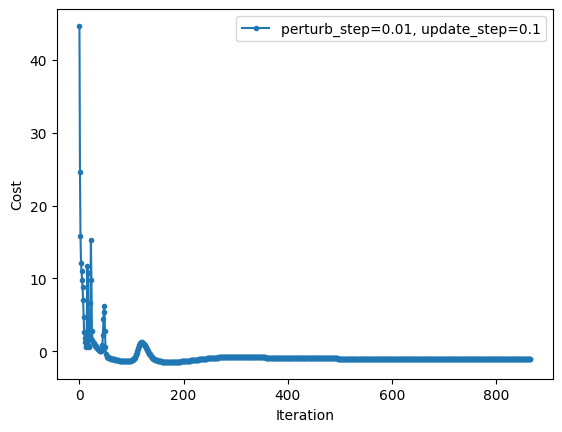

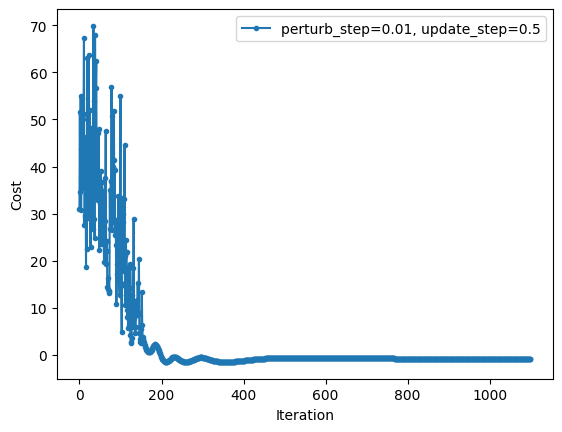

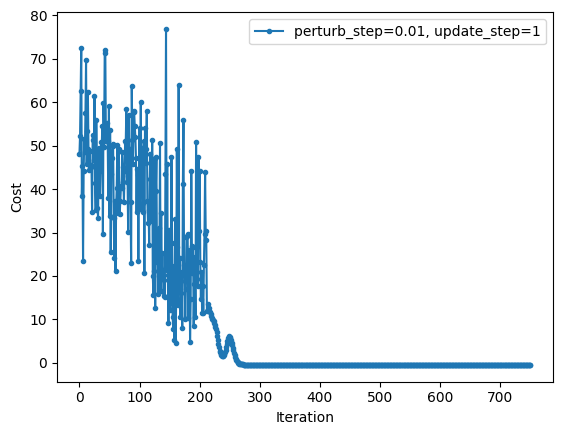

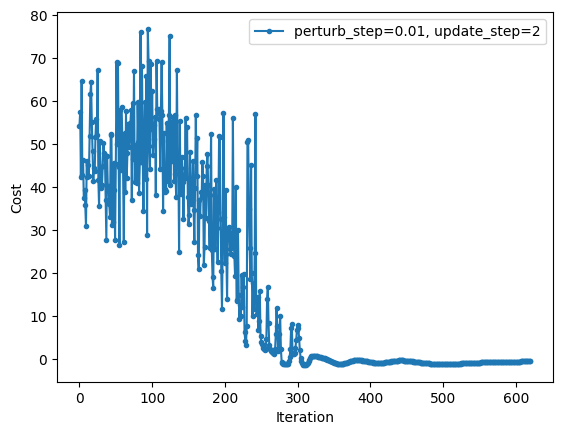

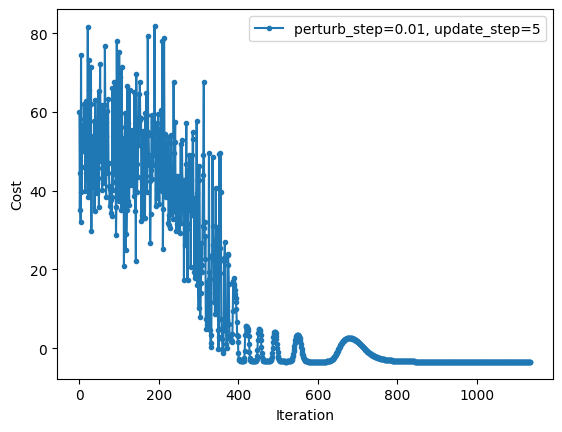

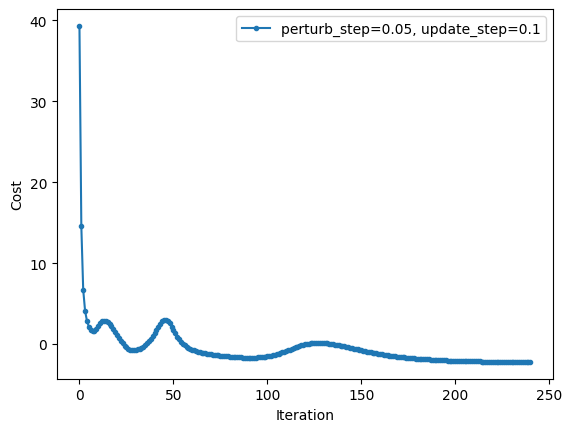

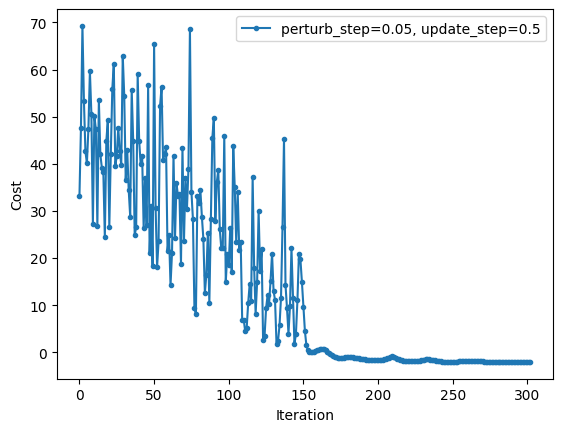

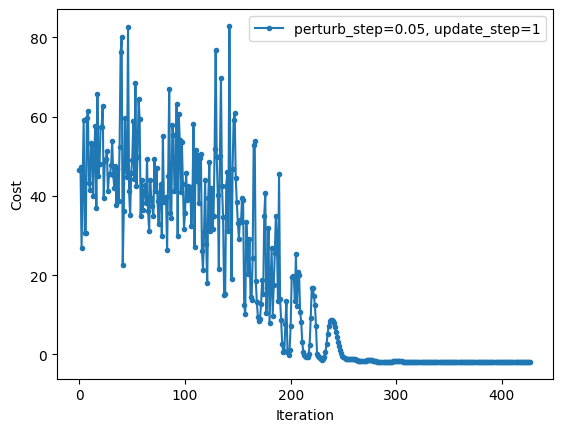

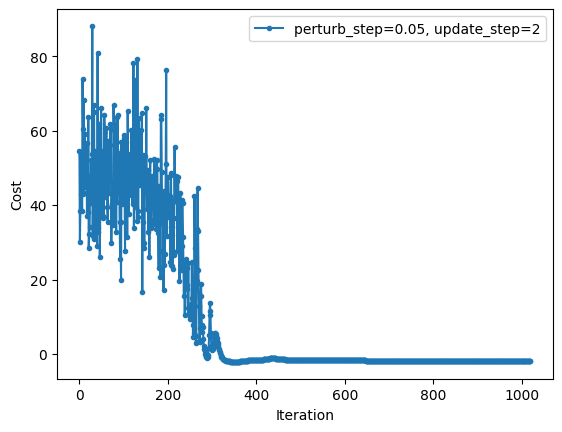

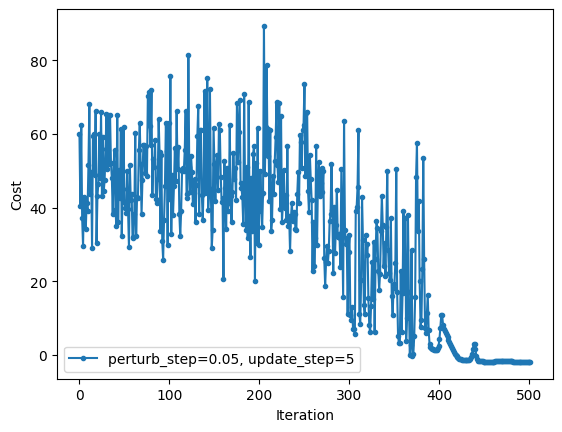

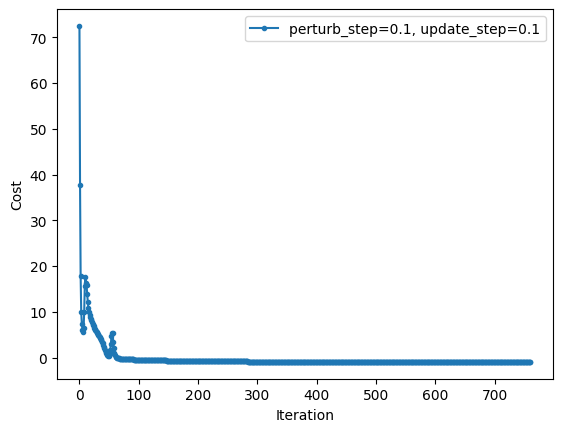

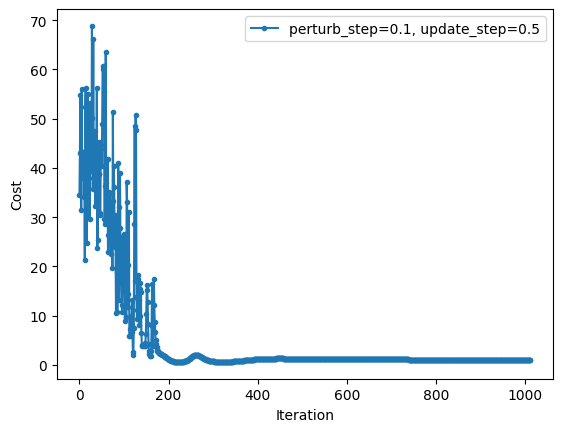

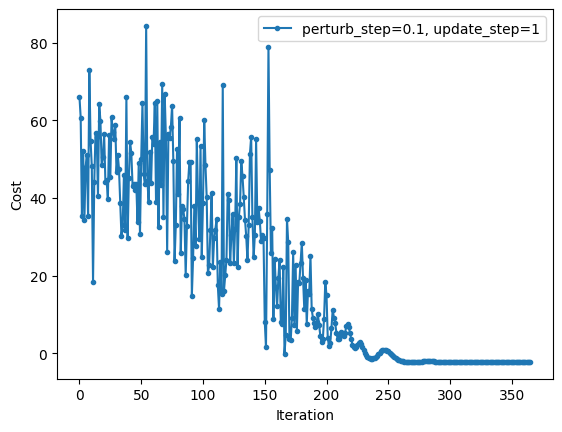

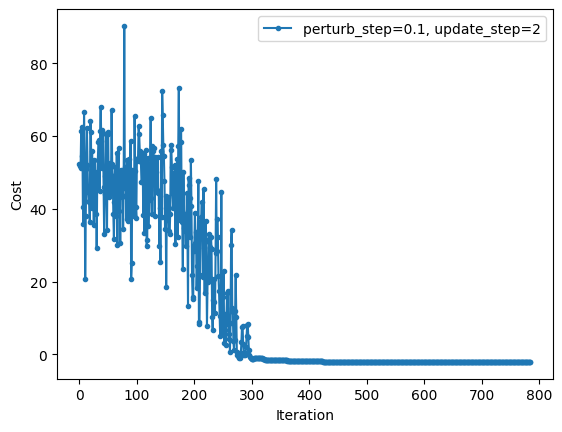

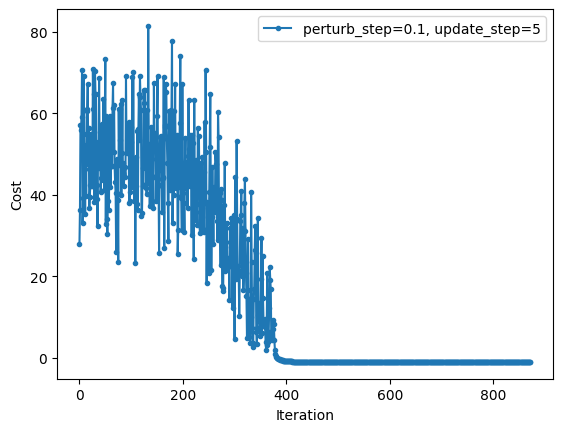

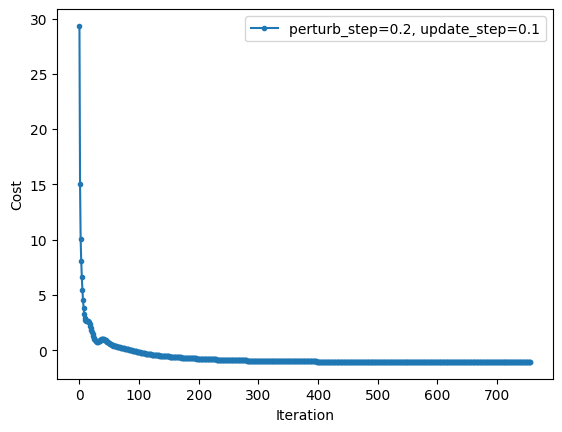

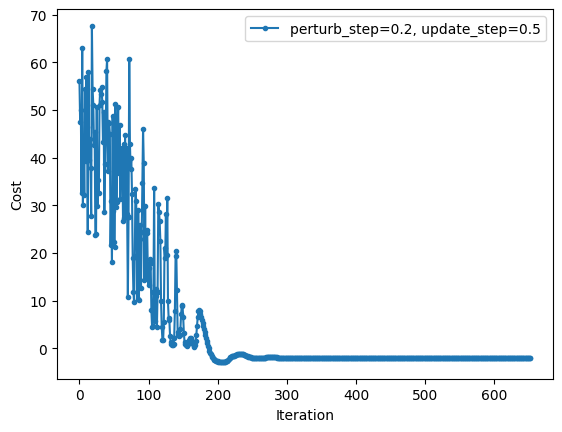

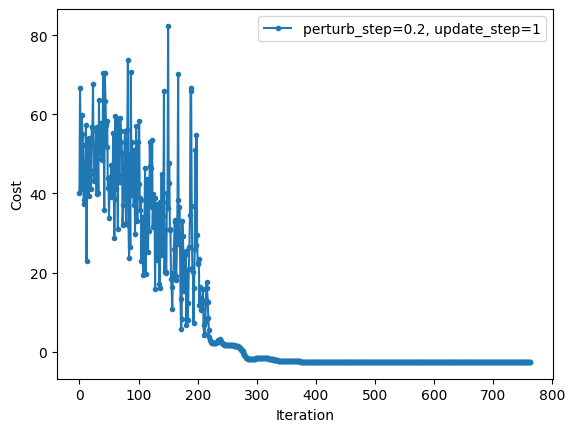

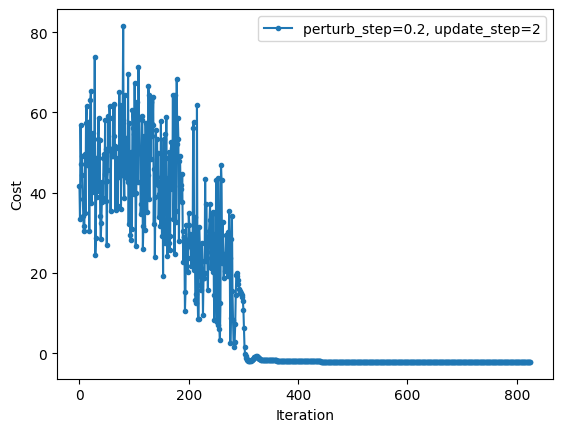

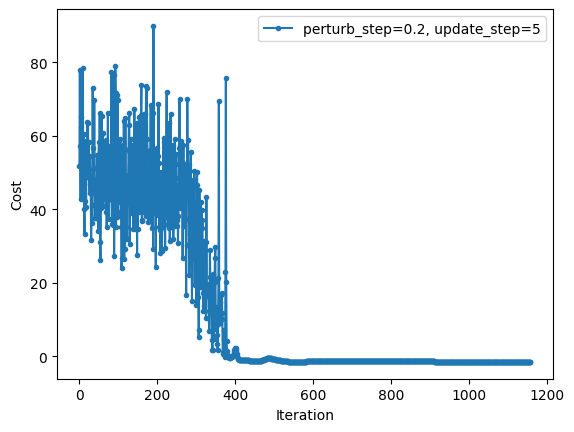

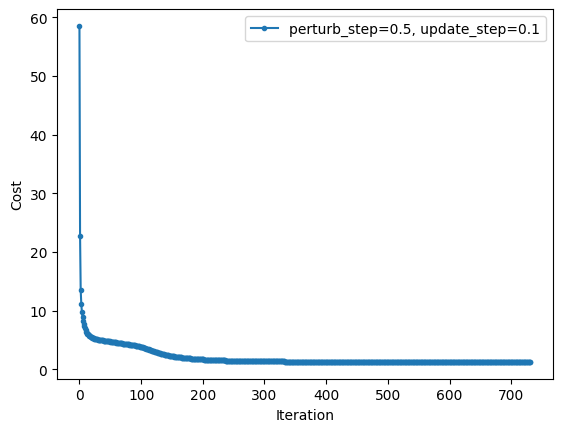

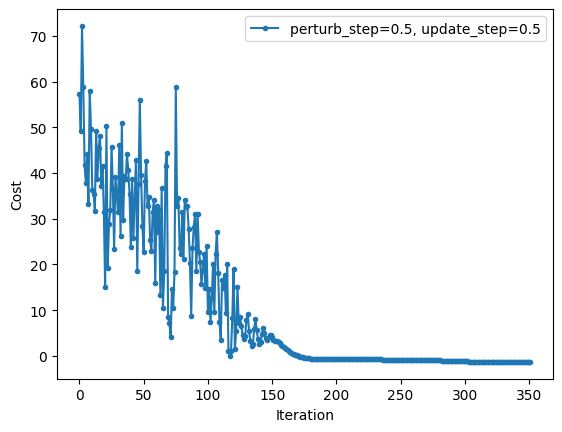

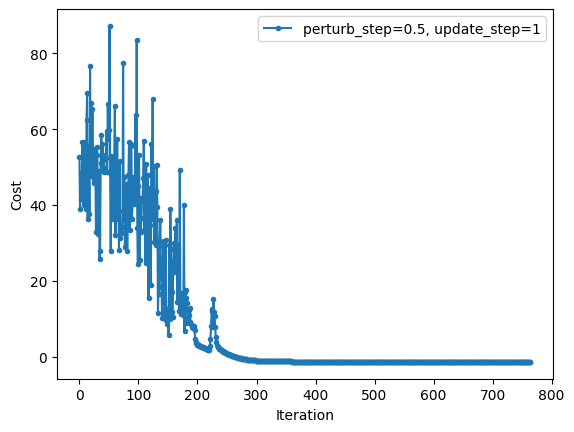

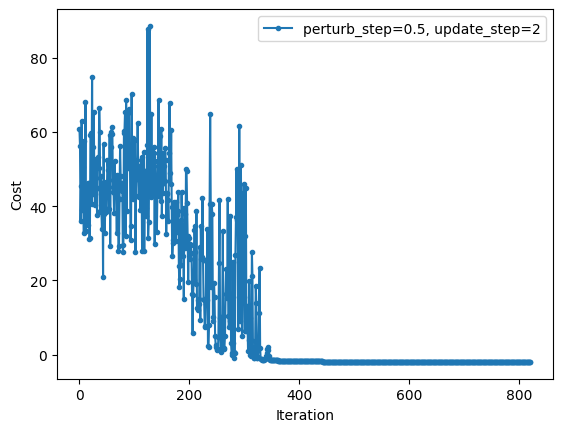

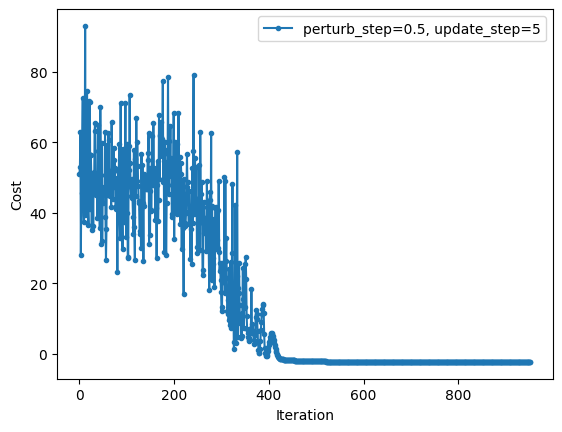

In [23]:
protein_folding_problem = build_pf(main_seq)
qubit_op = protein_folding_problem.qubit_op()

ansatz = TwoLocal(
    qubit_op.num_qubits,
    ["ry"],
    "cx",
    reps=2,
    entanglement="linear",
    skip_final_rotation_layer=True,
)

dir = "vqec_results/step_size_grid_search/"

for filename in sorted(os.listdir(dir)):
    # Check if the file is a JSON file
    if filename.endswith(".json"):
        # Open the JSON file
        with open(os.path.join(dir, filename), "r") as f:
            # Load the JSON data
            data = json.load(f)
            perturb_step = data["primal_perturb_step"]
            update_step = data["primal_dual_update_step"]
            # print(f"update step size = {update_step}, perturb step size = {perturb_step}")
            cost_trajectory = data["energies"]
            # Plot the cost trajectory
            plt.plot(cost_trajectory, label=f"perturb_step={perturb_step}, update_step={update_step}", marker=".")
            plt.xlabel("Iteration")
            plt.ylabel("Cost")
            plt.legend()
            plt.show()

In [20]:
cs_dir = "../classical_search/cs_res/"


def relabel_turns(turns: str) -> str:
    """Relabels the turns from the classical search to the ones used in the quantum search."""
    mapping = {
        "0": "0",
        "1": "2",
        "2": "4",
        "3": "6",
        "4": "8",
        "5": "a",
        "6": "1",
        "7": "3",
        "8": "5",
        "9": "7",
        "a": "9",
        "b": "b",
    }
    return "".join([mapping[turn] for turn in turns])


def load_top_cls_solns(file_name: str) -> list[str]:
    top_cls_turns = []
    with open(cs_dir + file_name, "r") as file:
        data = file.read()
        # Split by line
        data_by_line = data.split("\n")
        for line in data_by_line:
            if len(line.split("\t")) == 2:
                [energy, turns] = line.split("\t")
                top_cls_turns.append([relabel_turns(turns), float(energy)])
    return top_cls_turns


def convert_bitstring_to_turns(soln_bitstring: str, main_seq: str) -> str:
    """Converts a solution bitstring (given by the quantum algorithm) to the
    turns."""
    encoding = {
        "0000": "0",
        "0011": "1",
        "1100": "2",
        "1111": "3",
        "1001": "4",
        "0101": "5",
        "1010": "6",
        "0110": "7",
        "1000": "8",
        "0100": "9",
        "1011": "a",
        "0111": "b",
        "0001": "x",  # unphysical
        "0010": "x",  # unphysical
        "1101": "x",  # unphysical
        "1110": "x",  # unphysical
    }
    peptide_len = len(main_seq)
    config_bitstring = soln_bitstring[-(4 * peptide_len - 10) :]
    # Add the first 4 bits corresponding to the fixed first turn (0000)
    full_config_bitstring = config_bitstring + "0000"
    # Add the two qubits at positions 6 & 7 from the right (00)
    full_config_bitstring = (
        full_config_bitstring[:-6] + "00" + full_config_bitstring[-6:]
    )
    # Reverse the bitstring
    full_config_bitstring = full_config_bitstring[::-1]
    length_turns = len(full_config_bitstring) // 4
    turns = ""
    for i in range(length_turns):
        turn = full_config_bitstring[i * 4 : (i + 1) * 4]
        turns += encoding[turn]
    # Reverse the turns
    return turns[::-1]

In [21]:
# Loop through the files in the directory
for filename in sorted(os.listdir(dir)):
    # Check if the file is a JSON file
    if filename.endswith(".json"):
        # Open the JSON file
        with open(os.path.join(dir, filename), "r") as f:
            # Load the JSON data
            data = json.load(f)
            perturb_step = data["primal_perturb_step"]
            update_step = data["primal_dual_update_step"]
            print(f"\n perturb_step = {perturb_step}, update_step = {update_step}")
            # Get the optimized variational parameters
            optimal_primal_vars = data["optimal_primal_vars"]
            sorted_quasi_dist = sample_optimized_circ(ansatz, optimal_primal_vars, shots=100000)
            # Compute the energies of all samples
            bitstring_energies = {}
            for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
                if i >= 5:
                    break
                energy = _evaluate_sparsepauli(sample, qubit_op)
                # Check for overlaps
                overlaps = check_overlaps(peptide, sample)
                turns = convert_bitstring_to_turns(sample, main_seq)
                bitstring_energies[sample] = (turns, energy, prob, overlaps)
                print(f"{sample} (turns: {turns}) with probability {prob}, energy {energy}, and overlaps {overlaps}")


 perturb_step = 0.01, update_step = 0.1


/var/folders/6z/68dj05v5057cwh6yv32zx6380000gp/T/ipykernel_27212/1207470909.py:28: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": shots})


110101101100100000011011 (turns: 90720) with probability 0.01959, energy -2.8680000000000017, and overlaps [(2, 5)]
110100111100100000011011 (turns: 90720) with probability 0.01908, energy -1.1320000000000017, and overlaps [(2, 5)]
001011101100100000011011 (turns: 90720) with probability 0.01369, energy -2.0410000000000013, and overlaps [(2, 5)]
110101101101100000011011 (turns: 70720) with probability 0.01224, energy 0.7999999999999983, and overlaps None
001010111100100000011011 (turns: 90720) with probability 0.01155, energy -0.30500000000000094, and overlaps [(2, 5)]

 perturb_step = 0.01, update_step = 0.5
001110011111100001101010 (turns: b8590) with probability 0.08916, energy -2.096999999999999, and overlaps [(0, 5)]
001110111111100001101010 (turns: b8590) with probability 0.0879, energy -2.4899999999999993, and overlaps [(0, 5)]
001110011011100001101010 (turns: b8590) with probability 0.08697, energy -1.8479999999999985, and overlaps [(0, 5)]
001110111011100001101010 (turns: b859

In [22]:
cls_file_name = "6AA_KLVFFA_topobj.txt"
top_cls_turns = load_top_cls_solns(cls_file_name)[:20]
top_cls_turns

[['97490', -30.57],
 ['a9720', -30.55],
 ['8b520', -30.55],
 ['70b90', -30.45],
 ['81490', -30.45],
 ['31a20', -30.43],
 ['31820', -30.43],
 ['2b580', -30.43],
 ['9a180', -30.43],
 ['5b580', -30.33],
 ['1a180', -30.33],
 ['68b90', -30.25],
 ['02180', -30.23],
 ['70390', -30.13],
 ['68390', -30.13],
 ['82180', -30.13],
 ['07490', -30.13],
 ['7b090', -29.56],
 ['91820', -29.56],
 ['b1a20', -29.56]]

In [18]:
print(convert_bitstring_to_turns("011110101011010000111010", main_seq))
print(convert_bitstring_to_turns("001100011100011001110010", main_seq))

a0b90
84190


## Miscellaneous

In [11]:
ansatz = TwoLocal(qubit_op.num_qubits, ['ry'], 'cx', reps=1, entanglement='linear', skip_final_rotation_layer=True)
init_params = [np.random.rand(ansatz.num_parameters)]
# estimator = Estimator(backend_options={'method': 'statevector'})
estimator = Estimator(backend_options={'method': 'matrix_product_state'}, run_options={'shots': None}, approximation=True)
gradient_1 = LinCombEstimatorGradient(estimator=estimator)
gradient_2 = ParamShiftEstimatorGradient(estimator=estimator)
gradient_3 = FiniteDiffEstimatorGradient(estimator=estimator, epsilon=0.001)

In [16]:
grad_result_1 = gradient_1.run(circuits=ansatz, observables=qubit_op, parameter_values=init_params)
grad_result_1.result().gradients

[array([-24.6522316 ,  -8.3543522 , -15.33924042, -17.66810352,
        -24.91474543,  -5.3918116 ,  -7.38997048,  -0.99347861,
        -21.46319724, -18.40985139,   8.06716479,  -2.99647204,
         -0.88005039,  17.75540077,   1.55650454,  25.54264364,
         12.80644996,   4.51805965,  11.71222944,   4.05098697,
          6.9476704 ,   0.59124748,   0.2470542 ,   0.15424398])]

In [14]:
grad_result_2 = gradient_2.run(circuits=ansatz, observables=qubit_op, parameter_values=init_params)
grad_result_2.result().gradients

[array([-24.6522316 ,  -8.3543522 , -15.33924042, -17.66810352,
        -24.91474543,  -5.3918116 ,  -7.38997048,  -0.99347861,
        -21.46319724, -18.40985139,   8.06716479,  -2.99647204,
         -0.88005039,  17.75540077,   1.55650454,  25.54264364,
         12.80644996,   4.51805965,  11.71222944,   4.05098697,
          6.9476704 ,   0.59124748,   0.2470542 ,   0.154244  ])]

In [13]:
grad_result_3 = gradient_3.run(circuits=ansatz, observables=qubit_op, parameter_values=init_params)
grad_result_3.result().gradients

[array([-24.6522275 ,  -8.3543508 , -15.33923786, -17.66810057,
        -24.91474127,  -5.39181071,  -7.38996925,  -0.99347845,
        -21.46319366, -18.40984832,   8.06716344,  -2.99647154,
         -0.88005024,  17.75539781,   1.55650428,  25.54263939,
         12.80644782,   4.5180589 ,  11.71222749,   4.05098629,
          6.94766924,   0.59124738,   0.24705416,   0.15424398])]